# Recurrent Neural Networks in PyTorch: RNN and LSTM Step by Step

This notebook explains **how a vanilla RNN and an LSTM work internally** using small, fully transparent examples.
We start with sequences where each time step is a **single scalar** and compute all intermediate values explicitly.
Then we introduce a simple classification task, and finally we show the same concepts for **vector inputs**.

The emphasis is on:
- tensor shapes,
- what each variable represents,
- what each parameter does,
- what the model outputs at each step.


## 0) Imports and small helper functions

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)

def sigmoid(x: torch.Tensor) -> torch.Tensor:
    """Elementwise logistic sigmoid."""
    return 1.0 / (1.0 + torch.exp(-x))

def tanh(x: torch.Tensor) -> torch.Tensor:
    """Elementwise hyperbolic tangent."""
    return torch.tanh(x)


## 1) Scalar sequence input

We use a 1D tensor `x` where each element is one time step value.

- `x[t]` is the scalar at time step `t`
- `T` is the sequence length (number of time steps)

In PyTorch:
- `x.numel()` returns the **number of elements** in the tensor.
- Here that equals the number of time steps.


In [2]:
# A sequence of scalars (one scalar per time step)
x = torch.tensor([1.0, 0.0, 2.0, -1.0, 1.0])

# Sequence length: number of time steps
T = x.numel()  # numel = "number of elements" in the tensor

print("x:", x)
print("T (sequence length) =", T)


x: tensor([ 1.,  0.,  2., -1.,  1.])
T (sequence length) = 5


## 2) Vanilla RNN computed explicitly (hidden size H=1)

We implement a vanilla RNN with **one hidden unit**. That means the hidden state is a single scalar:

- `h_t` is the hidden state at time `t` (short-term memory)
- `h_0` is the initial hidden state (we set it to 0)

Update rule:
$$
h_t = \tanh( w_{ih}\,x_t + w_{hh}\,h_{t-1} + b )
$$

Parameter meanings (all are scalars in this toy example):
- `w_ih`: how strongly the current input influences the hidden state
- `w_hh`: how strongly the previous hidden state influences the new hidden state
- `b`: bias term


In [3]:
# ---- Fixed scalar parameters for a transparent example ----
w_ih = torch.tensor(0.8)   # input-to-hidden weight (scalar)
w_hh = torch.tensor(0.5)   # hidden-to-hidden (recurrent) weight (scalar)
b    = torch.tensor(0.0)   # bias (scalar)

h = torch.tensor(0.0)      # initial hidden state h0

history_rnn = []  # store values for printing and plotting

for t in range(T):
    # x_t is the scalar input at time step t
    x_t = x[t]

    # pre-activation a_t is the linear combination before tanh
    a_t = w_ih * x_t + w_hh * h + b

    # hidden state update
    h = tanh(a_t)

    # store everything for inspection
    history_rnn.append((t, float(x_t), float(a_t), float(h)))

print("t | x_t | a_t (pre-activation) | h_t (hidden state)")
for t, x_t, a_t, h_t in history_rnn:
    print(f"{t:1d} | {x_t:4.1f} | {a_t:8.4f}             | {h_t:8.4f}")


t | x_t | a_t (pre-activation) | h_t (hidden state)
0 |  1.0 |   0.8000             |   0.6640
1 |  0.0 |   0.3320             |   0.3203
2 |  2.0 |   1.7602             |   0.9425
3 | -1.0 |  -0.3287             |  -0.3174
4 |  1.0 |   0.6413             |   0.5658


### Interpretation of the variables

- `x_t`: the input value at time `t` (what we observe now)
- `h_{t-1}`: the previous hidden state (what the model remembered so far)
- `a_t`: the linear combination of the new input and the old hidden state
- `h_t`: the updated hidden state (the memory after seeing `x_t`)


### Plot the RNN hidden state over time

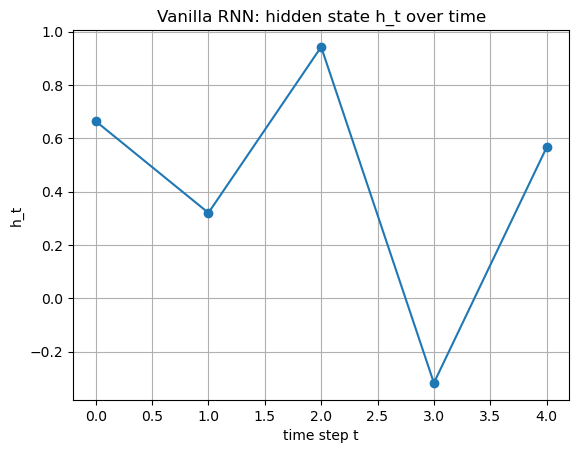

In [7]:
h_vals = [row[3] for row in history_rnn]

plt.figure()
plt.plot(range(T), h_vals, marker="o")
plt.title("Vanilla RNN: hidden state h_t over time")
plt.xlabel("time step t")
plt.ylabel("h_t")
plt.grid(True)
plt.show()


## 3) LSTM computed explicitly (hidden size H=1)

An LSTM has two states:
- `c_t`: **cell state** (often called long-term memory)
- `h_t`: **hidden state** (short-term output)

At each time step, the LSTM computes:
- `f_t` (forget gate): how much of the old cell state to keep
- `i_t` (input gate): how much new information to write into the cell state
- `o_t` (output gate): how much of the cell state to expose as hidden state
- `g_t` (candidate): the proposed new information content

Gate values are in `[0, 1]` because they use `sigmoid`.
The candidate `g_t` is in `[-1, 1]` because it uses `tanh`.

For a scalar LSTM (H=1), all of these are scalars.

We use the following toy equations:
- Gates: `sigmoid(w * x_t + u * h_{t-1} + b)`
- Candidate: `tanh(wg * x_t + ug * h_{t-1} + bg)`

Meanings of parameters:
- `w`: weight applied to the **current input** `x_t`
- `u`: weight applied to the **previous hidden state** `h_{t-1}`
- `b`: bias term

These are separate for each gate (`f`, `i`, `o`) and for the candidate (`g`).


In [12]:
# ---- Fixed scalar parameters for a transparent example ----
# Each gate uses: sigmoid(w*x_t + u*h_{t-1} + b)

# Forget gate parameters (w_f, u_f, b_f)
wf, uf, bf = torch.tensor(1.0), torch.tensor(0.5), torch.tensor(0.0)

# Input gate parameters (w_i, u_i, b_i)
wi, ui, bi = torch.tensor(1.0), torch.tensor(0.5), torch.tensor(0.0)

# Output gate parameters (w_o, u_o, b_o)
wo, uo, bo = torch.tensor(1.0), torch.tensor(0.5), torch.tensor(0.0)

# Candidate parameters (w_g, u_g, b_g): tanh(wg*x_t + ug*h_{t-1} + bg)
wg, ug, bg = torch.tensor(1.0), torch.tensor(0.5), torch.tensor(0.0)

# Initial states
h = torch.tensor(0.0)  # h0: initial hidden state
c = torch.tensor(0.0)  # c0: initial cell state

history_lstm = []

for t in range(T):
    x_t = x[t]  # current scalar input

    # Compute gates (numbers between 0 and 1)
    f = sigmoid(wf * x_t + uf * h + bf)  # forget gate
    i = sigmoid(wi * x_t + ui * h + bi)  # input gate
    o = sigmoid(wo * x_t + uo * h + bo)  # output gate

    # Candidate content (number between -1 and 1)
    g = tanh(wg * x_t + ug * h + bg)

    # Update cell state (long-term memory)
    c = f * c + i * g

    # Update hidden state (short-term output)
    h = o * tanh(c)

    history_lstm.append((t, float(x_t), float(f), float(i), float(o), float(g), float(c), float(h)))

print("t | x_t | f_t | i_t | o_t | g_t | c_t (cell state) | h_t (hidden)")
for row in history_lstm:
    t, x_t, f, i, o, g, c_t, h_t = row
    print(f"{t:1d} | {x_t:4.1f} | {f:5.3f} | {i:5.3f} | {o:5.3f} | {g:7.3f} | {c_t:14.4f} | {h_t:10.4f}")


t | x_t | f_t | i_t | o_t | g_t | c_t (cell state) | h_t (hidden)
0 |  1.0 | 0.731 | 0.731 | 0.731 |   0.762 |         0.5568 |     0.3696
1 |  0.0 | 0.546 | 0.546 | 0.546 |   0.183 |         0.4038 |     0.2093
2 |  2.0 | 0.891 | 0.891 | 0.891 |   0.971 |         1.2252 |     0.7498
3 | -1.0 | 0.349 | 0.349 | 0.349 |  -0.555 |         0.2338 |     0.0800
4 |  1.0 | 0.739 | 0.739 | 0.739 |   0.778 |         0.7475 |     0.4682


### Plot cell state c_t and hidden state h_t over time

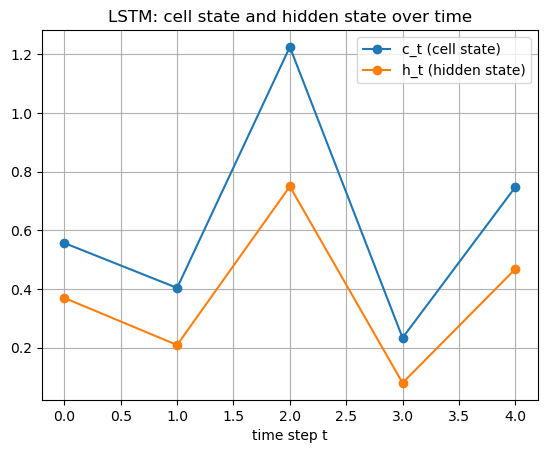

In [13]:
c_vals = [row[6] for row in history_lstm]
h_vals = [row[7] for row in history_lstm]

plt.figure()
plt.plot(range(T), c_vals, marker="o", label="c_t (cell state)")
plt.plot(range(T), h_vals, marker="o", label="h_t (hidden state)")
plt.title("LSTM: cell state and hidden state over time")
plt.xlabel("time step t")
plt.grid(True)
plt.legend()
plt.show()


## 4) Built-in PyTorch layers: nn.RNN and nn.LSTM on scalar sequences

Parameters:
- `input_size`: number of features per time step (D)
- `hidden_size`: number of hidden units (H)
- `batch_first=True`: use input shape (B, T, D)
- `nonlinearity="tanh"`: the nonlinearity used by nn.RNN

Returned values:
- RNN: `out, h_n`
- LSTM: `out, (h_n, c_n)`


In [14]:
x_seq = x.view(1, T, 1)  # (B=1, T, D=1)

rnn = nn.RNN(input_size=1, hidden_size=1, batch_first=True, nonlinearity="tanh")
lstm = nn.LSTM(input_size=1, hidden_size=1, batch_first=True)

out_rnn, h_n_rnn = rnn(x_seq)
out_lstm, (h_n_lstm, c_n_lstm) = lstm(x_seq)

print("Input shape:", x_seq.shape, "(B,T,D)")

print("\nRNN returns:")
print("  out_rnn:", out_rnn.shape, "  -> hidden state at each time step")
print("  h_n_rnn:", h_n_rnn.shape, "  -> final hidden state")

print("\nLSTM returns:")
print("  out_lstm:", out_lstm.shape, " -> hidden state at each time step")
print("  h_n_lstm:", h_n_lstm.shape, " -> final hidden state")
print("  c_n_lstm:", c_n_lstm.shape, " -> final cell state")


Input shape: torch.Size([1, 5, 1]) (B,T,D)

RNN returns:
  out_rnn: torch.Size([1, 5, 1])   -> hidden state at each time step
  h_n_rnn: torch.Size([1, 1, 1])   -> final hidden state

LSTM returns:
  out_lstm: torch.Size([1, 5, 1])  -> hidden state at each time step
  h_n_lstm: torch.Size([1, 1, 1])  -> final hidden state
  c_n_lstm: torch.Size([1, 1, 1])  -> final cell state


## 5) Many-to-one classification with scalar sequences

We build a toy dataset:
- input X: (N, T, 1)
- label y: (N,)

Label definition:
- y = 1 if sum over time is positive, else 0


In [42]:
def make_dataset(n: int = 2000, T: int = 20):
    X = torch.randn(n, T, 1)                # (N, T, D=1)
    y = (X.sum(dim=1)[:, 0] > 0).long()     # (N,)
    return X, y

X_train, y_train = make_dataset(n=2000, T=20)
X_val, y_val     = make_dataset(n=500,  T=20)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("Positive class fraction:", y_train.float().mean().item())


X_train: torch.Size([2000, 20, 1]) y_train: torch.Size([2000])
Positive class fraction: 0.5130000114440918


In [43]:
class ManyToOneModel(nn.Module):
    def __init__(self, cell: str = "rnn", hidden_size: int = 16):
        super().__init__()
        if cell == "rnn":
            self.core = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        elif cell == "lstm":
            self.core = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        else:
            raise ValueError("cell must be 'rnn' or 'lstm'")

        self.fc = nn.Linear(hidden_size, 2)  # binary classification -> 2 classes

    def forward(self, x):
        # x: (B, T, 1)
        out, _ = self.core(x)         # out: (B, T, H)
        h_last = out[:, -1, :]        # (B, H), last time step hidden state
        logits = self.fc(h_last)      # (B, 2)
        return logits


### Training function with detailed comments

Arguments:
- `model`: the classifier (RNN-based or LSTM-based)
- `X, y`: training data and labels
- `Xv, yv`: validation data and labels
- `epochs`: number of passes over the training set
- `lr`: learning rate
- `batch_size`: mini-batch size

Inside the loop:
- sample a mini-batch
- compute logits (forward pass)
- compute loss
- backpropagate gradients
- update parameters


In [44]:
def train_simple(model, X, y, Xv, yv, epochs: int = 5, lr: float = 1e-3, batch_size: int = 64):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    def accuracy_from_logits(logits, y_true):
        preds = logits.argmax(dim=1)
        return (preds == y_true).float().mean().item()

    n = X.size(0)

    for ep in range(1, epochs + 1):
        # --- TRAINING ---
        model.train()  # enable training mode
        perm = torch.randperm(n)  # shuffle indices

        total_loss = 0.0
        n_batches = 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]  # indices for this mini-batch
            xb = X[idx]  # xb: (B, T, 1)
            yb = y[idx]  # yb: (B,)

            opt.zero_grad(set_to_none=True)  # reset gradients
            logits = model(xb)               # forward: (B, 2)
            loss = loss_fn(logits, yb)       # scalar loss
            loss.backward()                  # compute gradients
            opt.step()                       # update weights

            total_loss += loss.item()
            n_batches += 1

        # --- VALIDATION ---
        model.eval()
        with torch.no_grad():
            val_logits = model(Xv)  # (N_val, 2)
            val_acc = accuracy_from_logits(val_logits, yv)

        print(f"epoch {ep:02d} | train_loss={total_loss/n_batches:.4f} | val_acc={val_acc:.3f}")


In [45]:
print("Training RNN model")
m_rnn = ManyToOneModel(cell="rnn", hidden_size=16)
train_simple(m_rnn, X_train, y_train, X_val, y_val, epochs=5)

print("\nTraining LSTM model")
m_lstm = ManyToOneModel(cell="lstm", hidden_size=16)
train_simple(m_lstm, X_train, y_train, X_val, y_val, epochs=5)


Training RNN model
epoch 01 | train_loss=0.6739 | val_acc=0.708
epoch 02 | train_loss=0.5154 | val_acc=0.872
epoch 03 | train_loss=0.3181 | val_acc=0.910
epoch 04 | train_loss=0.2500 | val_acc=0.904
epoch 05 | train_loss=0.2232 | val_acc=0.908

Training LSTM model
epoch 01 | train_loss=0.7050 | val_acc=0.526
epoch 02 | train_loss=0.6831 | val_acc=0.740
epoch 03 | train_loss=0.6017 | val_acc=0.932
epoch 04 | train_loss=0.3947 | val_acc=0.914
epoch 05 | train_loss=0.2950 | val_acc=0.912


## 6) Vector inputs (D > 1) and output shapes

Now each time step input is a vector of length `D`.

Definitions:
- `B`: number of sequences in a batch
- `T`: number of time steps per sequence
- `D`: number of features per time step (input_size)
- `H`: number of hidden units (hidden_size)

We show what each returned tensor represents.


In [46]:
B, T, D, H = 2, 6, 4, 8
x_vec = torch.randn(B, T, D)  # input batch

rnn_vec = nn.RNN(input_size=D, hidden_size=H, batch_first=True)
lstm_vec = nn.LSTM(input_size=D, hidden_size=H, batch_first=True)

out_rnn, h_last = rnn_vec(x_vec)
out_lstm, (h_last_l, c_last_l) = lstm_vec(x_vec)

print("x_vec:", x_vec.shape, " -> (B,T,D) input")

print("\nRNN:")
print("  out_rnn:", out_rnn.shape, " -> (B,T,H), hidden state for every time step")
print("  h_last:", h_last.shape, " -> (1,B,H), final hidden state for the sequence")

print("\nLSTM:")
print("  out_lstm:", out_lstm.shape, " -> (B,T,H), hidden state for every time step")
print("  h_last_l:", h_last_l.shape, " -> (1,B,H), final hidden state for the sequence")
print("  c_last_l:", c_last_l.shape, " -> (1,B,H), final cell state (long-term memory)")


x_vec: torch.Size([2, 6, 4])  -> (B,T,D) input

RNN:
  out_rnn: torch.Size([2, 6, 8])  -> (B,T,H), hidden state for every time step
  h_last: torch.Size([1, 2, 8])  -> (1,B,H), final hidden state for the sequence

LSTM:
  out_lstm: torch.Size([2, 6, 8])  -> (B,T,H), hidden state for every time step
  h_last_l: torch.Size([1, 2, 8])  -> (1,B,H), final hidden state for the sequence
  c_last_l: torch.Size([1, 2, 8])  -> (1,B,H), final cell state (long-term memory)


## 7) Summary

- `T = x.numel()` is the number of time steps because `x` is a 1D tensor of length `T`.
- In the scalar examples, parameters like `wf`, `uf`, `bf` are scalar versions of the matrices used in real LSTMs.
- In a real LSTM, gates are computed from both input `x_t` and previous hidden state `h_{t-1}` using learned weights.
